Posición WCS aproximada:
x = 292.503, y = 440.330
Centro de luz encontrado en:
x = 293, y = 440


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


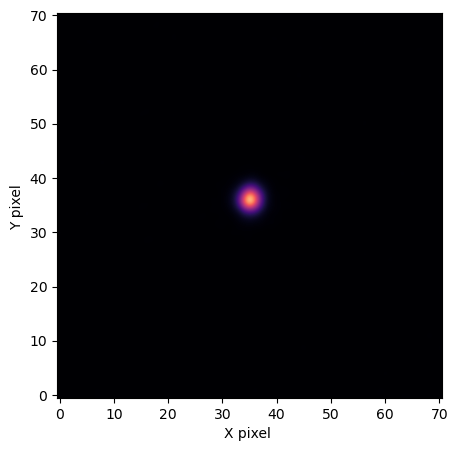

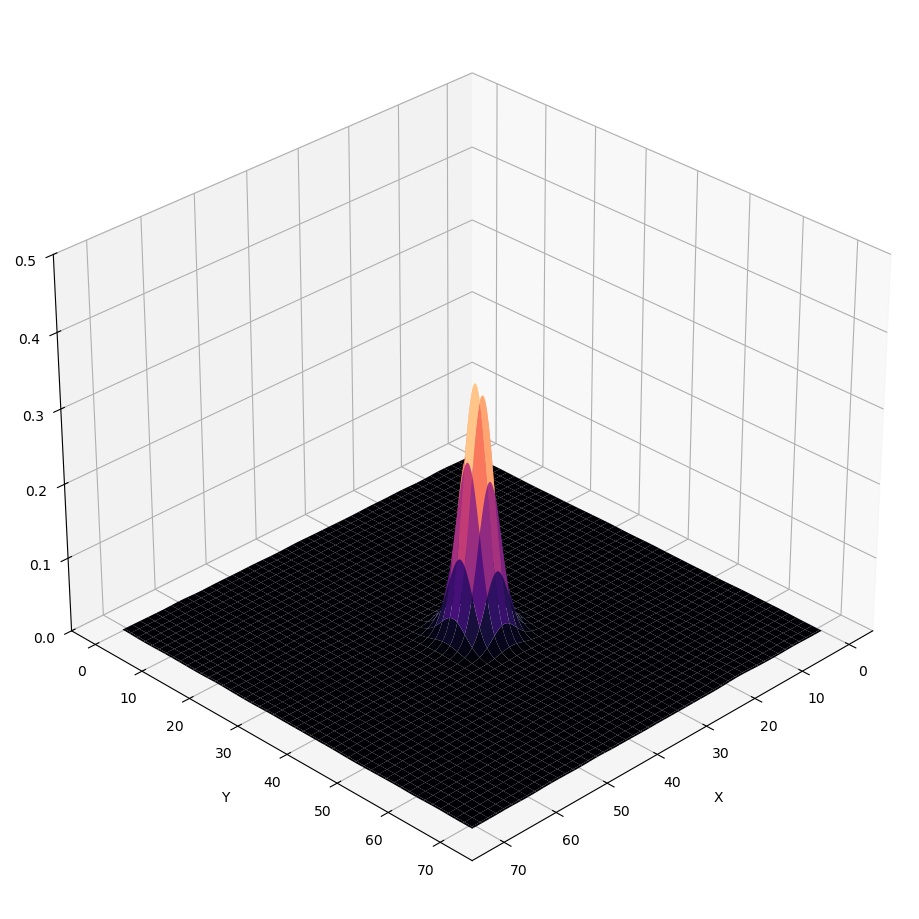

In [2]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import zoom, gaussian_filter


fits_path = r"C:\Users\ivanf\OneDrive\Escritorio\APT intento\WD\wd_g.fits"
ra_deg = 188.54312583368
dec_deg = -02.46749608412

search_half_size = 20
cut_half_size = 35
zoom_factor = 8
smooth_sigma = 15

with fits.open(fits_path) as hdul:
    data = hdul[0].data
    header = hdul[0].header

if data.ndim > 2:
    data = data[0]

wcs = WCS(header)

coord = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
x_pix, y_pix = wcs.world_to_pixel(coord)

x_pix = float(np.squeeze(x_pix))
y_pix = float(np.squeeze(y_pix))

xi = int(np.round(x_pix))
yi = int(np.round(y_pix))

print("Posición WCS aproximada:")
print(f"x = {x_pix:.3f}, y = {y_pix:.3f}")

ymin = max(0, yi - search_half_size)
ymax = min(data.shape[0], yi + search_half_size + 1)
xmin = max(0, xi - search_half_size)
xmax = min(data.shape[1], xi + search_half_size + 1)

search_cut = data[ymin:ymax, xmin:xmax]

search_bgsub = search_cut - np.nanmedian(search_cut)
search_bgsub[search_bgsub < 0] = 0

yy_s, xx_s = np.indices(search_bgsub.shape)

total_flux = np.sum(search_bgsub)

if total_flux > 0:
    x_cen = np.sum(xx_s * search_bgsub) / total_flux
    y_cen = np.sum(yy_s * search_bgsub) / total_flux
else:
    jmax, imax = np.unravel_index(np.nanargmax(search_cut), search_cut.shape)
    x_cen, y_cen = imax, jmax

x_peak = xmin + int(x_cen)
y_peak = ymin + int(y_cen)

print("Centro de luz encontrado en:")
print(f"x = {x_peak}, y = {y_peak}")

ymin2 = max(0, y_peak - cut_half_size)
ymax2 = min(data.shape[0], y_peak + cut_half_size + 1)
xmin2 = max(0, x_peak - cut_half_size)
xmax2 = min(data.shape[1], x_peak + cut_half_size + 1)

psf_cut = data[ymin2:ymax2, xmin2:xmax2]

background = np.nanmedian(search_cut)
peak_value = np.nanmax(psf_cut)
net_peak = peak_value - background


psf_cut_bgsub = psf_cut - background
psf_cut_bgsub[psf_cut_bgsub < 0] = 0

if np.nanmax(psf_cut_bgsub) > 0:
    psf_norm = psf_cut_bgsub / np.nanmax(psf_cut_bgsub)
else:
    psf_norm = psf_cut_bgsub.copy()

plt.figure(figsize=(6, 5))
plt.imshow(psf_norm, origin="lower", cmap="magma", interpolation="bicubic")
plt.xlabel("X pixel ")
plt.ylabel("Y pixel ")
plt.show()

psf_smooth = zoom(psf_norm, zoom_factor)
psf_smooth = gaussian_filter(psf_smooth, sigma=smooth_sigma)

yy_s, xx_s = np.indices(psf_smooth.shape)

xx_plot = xx_s / zoom_factor
yy_plot = yy_s / zoom_factor

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    xx_plot,
    yy_plot,
    psf_smooth,
    cmap="magma",
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("X", labelpad=10)
ax.set_ylabel("Y", labelpad=10)
ax.set_zlim(0, 0.5)
ax.view_init(elev=30, azim=45)

plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95)
plt.show()